# Skeleton-First 骨架优先解码实验

先填每个 block 的首尾 token（骨架），再用 DualCache 逐 block 填充剩余位置。

| 阶段 | 说明 |
|------|------|
| **Round 1 (Skeleton)** | 全量 forward，只解码每个 block 的第 0 和第 31 个位置，threshold=0.9 |
| **Round 2 (Fill)** | DualCache block-by-block，threshold=0.9，骨架 token 充当上下文锚点 |

## 1. 环境设置

In [1]:
import os, sys, gc
import torch
import torch.nn.functional as F
import numpy as np

os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2,3'
NUM_GPUS = 4
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['HF_ALLOW_CODE_EVAL'] = '1'
os.environ['HF_DATASETS_TRUST_REMOTE_CODE'] = 'true'

os.chdir(os.path.join(os.path.dirname(os.path.abspath('__file__')), 'llada'))
print(f'Working dir: {os.getcwd()}')

torch.cuda.empty_cache(); gc.collect()
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}, VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')

Working dir: /data/houpu/tfast/fastllmskip/llada
GPU: NVIDIA RTX A5000, VRAM: 22.1 GB


## 2. 模型 & 数据加载

In [2]:
from transformers import AutoTokenizer, AutoConfig
from model.modeling_llada import LLaDAModelLM
from generate import get_num_transfer_tokens, get_transfer_index
from datasets import load_dataset

MODEL_PATH = 'GSAI-ML/LLaDA-8B-Instruct'
MASK_ID = 126336

config = AutoConfig.from_pretrained(MODEL_PATH)
config.flash_attention = True
model = LLaDAModelLM.from_pretrained(
    MODEL_PATH, trust_remote_code=True, torch_dtype=torch.bfloat16, config=config,
).eval().to('cuda')
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)

gsm8k = load_dataset('gsm8k', 'main', split='test')
print(f'Model loaded. GSM8K test: {len(gsm8k)} samples')

/data/houpu/miniconda3/envs/fastllm/lib/python3.10/site-packages/transformers/utils/hub.py:106: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Model loaded. GSM8K test: 1319 samples


In [3]:
FEW_SHOT_EXAMPLES = """Question: Jen and Tyler are gymnasts practicing flips. Jen is practicing the triple-flip while Tyler is practicing the double-flip. Jen did sixteen triple-flips during practice. Tyler flipped in the air half the number of times Jen did. How many double-flips did Tyler do?
Answer: Jen did 16 triple-flips, so she did 16 * 3 = <<16*3=48>>48 flips.
Tyler did half the number of flips, so he did 48 / 2 = <<48/2=24>>24 flips.
A double flip has two flips, so Tyler did 24 / 2 = <<24/2=12>>12 double-flips.
#### 12

Question: Four people in a law firm are planning a party. Mary will buy a platter of pasta for $20 and a loaf of bread for $2. Elle and Andrea will split the cost for buying 4 cans of soda which cost $1.50 each, and chicken wings for $10. Joe will buy a cake that costs $5. How much more will Mary spend than the rest of the firm put together?
Answer: Mary will spend $20 + $2 = $<<20+2=22>>22.
Elle and Andrea will spend $1.5 x 4 = $<<1.5*4=6>>6 for the soda.
Elle and Andrea will spend $6 + $10 = $<<6+10=16>>16 for the soda and chicken wings.
Elle, Andrea, and Joe together will spend $16 + $5 = $<<16+5=21>>21.
So, Mary will spend $22 - $21 = $<<22-21=1>>1 more than all of them combined.
#### 1

Question: A charcoal grill burns fifteen coals to ash every twenty minutes of grilling. The grill ran for long enough to burn three bags of coals. Each bag of coal contains 60 coals. How long did the grill run?
Answer: The grill burned 3 * 60 = <<3*60=180>>180 coals.
It takes 20 minutes to burn 15 coals, so the grill ran for 180 / 15 * 20 = <<180/15*20=240>>240 minutes.
#### 240

Question: A bear is preparing to hibernate for the winter and needs to gain 1000 pounds. At the end of summer, the bear feasts on berries and small woodland animals. During autumn, it devours acorns and salmon. It gained a fifth of the weight it needed from berries during summer, and during autumn, it gained twice that amount from acorns. Salmon made up half of the remaining weight it had needed to gain. How many pounds did it gain eating small animals?
Answer: The bear gained 1 / 5 * 1000 = <<1/5*1000=200>>200 pounds from berries.
It gained 2 * 200 = <<2*200=400>>400 pounds from acorns.
It still needed 1000 - 200 - 400 = <<1000-200-400=400>>400 pounds.
Thus, it gained 400 / 2 = <<400/2=200>>200 pounds from salmon.
Therefore, the bear gained 400 - 200 = <<400-200=200>>200 pounds from small animals.
#### 200

Question: Brendan can cut 8 yards of grass per day, he bought a lawnmower and it helped him to cut more yards by Fifty percent per day. How many yards will Brendan be able to cut after a week?
Answer: The additional yard Brendan can cut after buying the lawnmower is 8 x 0.50 = <<8*0.50=4>>4 yards.
So, the total yards he can cut with the lawnmower is 8 + 4 = <<8+4=12>>12.
Therefore, the total number of yards he can cut in a week is 12 x 7 = <<12*7=84>>84 yards.
#### 84"""


def build_prompt(question: str) -> torch.Tensor:
    text = FEW_SHOT_EXAMPLES + f'\n\nQuestion: {question}\nAnswer:'
    messages = [{'role': 'user', 'content': text}]
    formatted = tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    ids = tokenizer(formatted)['input_ids']
    return torch.tensor(ids, dtype=torch.long, device='cuda').unsqueeze(0)


LIMIT = 200
prompts = [build_prompt(gsm8k[i]['question']) for i in range(LIMIT)]
ref_answers = [gsm8k[i]['answer'] for i in range(LIMIT)]
print(f'Built {len(prompts)} prompts, first length: {prompts[0].shape[1]} tokens')

Built 400 prompts, first length: 1075 tokens


## 3. GSM8K 答案解析

In [4]:
import re

def extract_answer(text: str) -> str | None:
    """Extract numeric answer after ####"""
    m = re.search(r'####\s*(-?[\d,]+\.?\d*)', text)
    return m.group(1).replace(',', '').strip() if m else None


def decode_and_evaluate(x, prompt, ref_answer):
    """Decode generated tokens, extract answer, check correctness."""
    gen_ids = x[0, prompt.shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True)
    
    # Stop at common terminators
    for stop in ['Question:', '\n\nQuestion']:
        if stop in gen_text:
            gen_text = gen_text.split(stop)[0]

    gen_ans = extract_answer(gen_text)
    ref_ans = extract_answer(ref_answer)
    correct = (gen_ans is not None and ref_ans is not None and gen_ans == ref_ans)
    return gen_text, gen_ans, ref_ans, correct

## 4. Skeleton-First 生成函数

In [5]:
@torch.no_grad()
def generate_skeleton_first(
    model, prompt,
    steps=256, gen_length=256, block_length=32,
    temperature=0., remasking='low_confidence', mask_id=MASK_ID,
    threshold=0.9,
):
    """Skeleton-First two-round generation.

    Round 1 (Skeleton): Full forward passes over the entire sequence, but only
        unmask block head+tail positions (2 per block). Iterate until all
        skeleton positions are filled or max steps exhausted.
    Round 2 (Fill): Standard DualCache block-by-block with remaining step
        budget. Skeleton tokens act as pre-filled context anchors.
    No correction in either round.
    """
    B = prompt.shape[0]
    Lp = int(prompt.shape[1])
    total_len = Lp + gen_length

    assert gen_length % block_length == 0
    num_blocks = gen_length // block_length

    x = torch.full((B, total_len), mask_id, dtype=torch.long, device=model.device)
    x[:, :Lp] = prompt

    nfe = 0
    corr_log = []

    # Skeleton positions: first and last token of each block (absolute indices)
    skeleton_abs = []
    for b in range(num_blocks):
        skeleton_abs.append(Lp + b * block_length)
        skeleton_abs.append(Lp + b * block_length + block_length - 1)
    skeleton_pos = torch.zeros(B, total_len, dtype=torch.bool, device=model.device)
    skeleton_pos[:, skeleton_abs] = True

    # ===== Round 1: Skeleton =====
    max_skeleton_steps = 2 * num_blocks
    for _ in range(max_skeleton_steps):
        skel_remaining = int((x[:, skeleton_abs] == mask_id).sum().item())
        if skel_remaining == 0:
            break

        out = model(x, use_cache=False)
        nfe += 1

        allowed = skeleton_pos & (x == mask_id)
        x0, ti = get_transfer_index(
            out.logits, temperature, remasking, allowed, x, None, threshold,
        )
        x = torch.where(ti, x0, x)

        new_remaining = int((x[:, skeleton_abs] == mask_id).sum().item())
        corr_log.append({
            'block': -1, 'type': 'skeleton', 'phase': 'skeleton',
            'threshold': threshold,
            'unmasked': int(ti.sum().item()), 'corrections': 0,
            'remaining': new_remaining,
        })

    # ===== Round 2: Fill (DualCache block-by-block) =====
    remaining_steps = max(steps - nfe, num_blocks)
    steps_per_block = max(remaining_steps // num_blocks, 1)

    for nb in range(num_blocks):
        s = Lp + nb * block_length
        e = s + block_length

        if (x[:, s:e] == mask_id).sum() == 0:
            continue

        block_mask = (x[:, s:e] == mask_id)
        num_tt = get_num_transfer_tokens(block_mask, steps_per_block)

        # WARM STEP
        out = model(x, use_cache=True)
        past_kv = out.past_key_values
        nfe += 1

        replace_pos = torch.zeros_like(x, dtype=torch.bool)
        replace_pos[:, s:e] = True

        global_mask = (x == mask_id)
        global_mask[:, e:] = False

        x0, ti = get_transfer_index(
            out.logits, temperature, remasking, global_mask, x, None, threshold,
        )
        x = torch.where(ti, x0, x)

        corr_log.append({
            'block': nb, 'type': 'warm', 'phase': 'fill',
            'threshold': threshold,
            'unmasked': int(ti.sum().item()), 'corrections': 0,
            'remaining': int((x[:, s:e] == mask_id).sum().item()),
        })

        # REFINE STEPS
        for i in range(1, steps_per_block):
            if (x[:, s:e] == mask_id).sum() == 0:
                break

            logits_blk = model(
                x[:, s:e], past_key_values=past_kv,
                use_cache=True, replace_position=replace_pos,
            ).logits

            mask_blk = (x[:, s:e] == mask_id)
            x0_blk, ti_blk = get_transfer_index(
                logits_blk, temperature, remasking, mask_blk, x[:, s:e], None, threshold,
            )
            blk_new = torch.where(ti_blk, x0_blk, x[:, s:e])
            x = torch.cat([x[:, :s], blk_new, x[:, e:]], dim=1)

            nfe += 1
            corr_log.append({
                'block': nb, 'type': 'refine', 'phase': 'fill',
                'threshold': threshold,
                'unmasked': int(ti_blk.sum().item()), 'corrections': 0,
                'remaining': int((x[:, s:e] == mask_id).sum().item()),
            })

    return x, nfe, {'log': corr_log, 'total_corrections': 0, 'nfe': nfe}

## 5. 运行 Skeleton-First 实验

In [6]:
import time as _time
import pickle
import subprocess
from tqdm.auto import tqdm

GEN_LENGTH = 256
STEPS = 256
BLOCK_LENGTH = 32
THRESHOLD = 0.9

# ---------- GPU allocation ----------
gpu_ids = os.environ.get('CUDA_VISIBLE_DEVICES', '0').split(',')
assert len(gpu_ids) >= 2, f"Need >= 2 GPUs, got {gpu_ids}"

OUT_DIR = 'correction_analysis/skeleton_v1'
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- 1. Launch baseline_t0.9 subprocess ----------
baseline_name = 'baseline_t0.9'
baseline_pkl = os.path.abspath(f'{OUT_DIR}/{baseline_name}.pkl')
baseline_cmd = [
    sys.executable, '_p0_runner.py',
    '--config_name', baseline_name,
    '--threshold', '0.9',
    '--correction', 'none',
    '--scope', 'block',
    '--limit', str(LIMIT),
    '--output_path', baseline_pkl,
    '--gen_length', str(GEN_LENGTH),
    '--steps', str(STEPS),
    '--block_length', str(BLOCK_LENGTH),
    '--save_details',
]
baseline_env = os.environ.copy()
baseline_env['CUDA_VISIBLE_DEVICES'] = str(gpu_ids[1])
print(f'[{baseline_name}] Launching on GPU {gpu_ids[1]} ...')
baseline_proc = subprocess.Popen(
    baseline_cmd, env=baseline_env,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
)

# ---------- 2. Skeleton-First in-process ----------
def _norm_ans(a):
    if a is None:
        return None
    try:
        v = float(a)
        return str(int(v)) if v == int(v) else str(v)
    except ValueError:
        return a

cfg_name = 'skeleton_first'
print(f'\n{"="*60}')
print(f'Config: {cfg_name}  (in-process, GPU {gpu_ids[0]})')
print(f'{"="*60}')

sk_results = []
total_nfe, total_gen_tokens = 0, 0
t0 = _time.time()

for idx in tqdm(range(LIMIT), desc=cfg_name):
    x_out, nfe, stats = generate_skeleton_first(
        model, prompts[idx],
        steps=STEPS, gen_length=GEN_LENGTH, block_length=BLOCK_LENGTH,
        threshold=THRESHOLD,
    )

    gen_text, gen_ans, ref_ans, correct = decode_and_evaluate(
        x_out, prompts[idx], ref_answers[idx],
    )

    gen_ids = x_out[0, prompts[idx].shape[1]:]
    num_gen_tokens = int((gen_ids != MASK_ID).sum().item())

    flex_matches = re.findall(r'-?[\d,]+\.?\d*', gen_text)
    flex_ans_str = flex_matches[-1].replace(',', '').strip() if flex_matches else None
    flex_ok = (_norm_ans(flex_ans_str) is not None and
               _norm_ans(ref_ans) is not None and
               _norm_ans(flex_ans_str) == _norm_ans(ref_ans))

    entry = {
        'idx': idx,
        'strict_ok': correct,
        'flex_ok': flex_ok,
        'strict_ans': gen_ans,
        'flex_ans': flex_ans_str,
        'ref_ans': ref_ans,
        'nfe': nfe,
        'corrections': 0,
        'num_gen_tokens': num_gen_tokens,
        'gen_text': gen_text,
        'corr_log': stats['log'],
    }
    sk_results.append(entry)
    total_nfe += nfe
    total_gen_tokens += num_gen_tokens

elapsed = _time.time() - t0
n = len(sk_results)

strict_acc = sum(r['strict_ok'] for r in sk_results) / n
flex_acc = sum(r['flex_ok'] for r in sk_results) / n
strict_se = (strict_acc * (1 - strict_acc) / n) ** 0.5
flex_se = (flex_acc * (1 - flex_acc) / n) ** 0.5

sk_output = {
    'config_name': cfg_name,
    'results': sk_results,
    'strict_acc': strict_acc,
    'flex_acc': flex_acc,
    'strict_se': strict_se,
    'flex_se': flex_se,
    'avg_nfe': total_nfe / n,
    'total_nfe': total_nfe,
    'avg_corrections': 0.0,
    'total_gen_tokens': total_gen_tokens,
    'tokens_per_second': total_gen_tokens / elapsed if elapsed > 0 else 0,
    'elapsed': elapsed,
    'n_samples': n,
}

with open(f'{OUT_DIR}/{cfg_name}.pkl', 'wb') as f:
    pickle.dump(sk_output, f)

print(f'  Flex Acc: {flex_acc:.2%}  Strict Acc: {strict_acc:.2%}  '
      f'Avg NFE: {total_nfe/n:.1f}  Time: {elapsed:.0f}s')
print(f'  Saved -> {OUT_DIR}/{cfg_name}.pkl')

# ---------- 3. Wait for baseline subprocess ----------
print(f'\n{"="*60}')
print('Waiting for baseline subprocess ...')
print(f'{"="*60}')
stdout, _ = baseline_proc.communicate()
print(f'\n--- {baseline_name} (exit={baseline_proc.returncode}) ---')
lines = stdout.strip().split('\n')
for line in lines[-15:]:
    print(f'  {line}')
if baseline_proc.returncode != 0:
    print(f'  [WARNING] {baseline_name} exited with code {baseline_proc.returncode}')

# ---------- 4. Merge all results ----------
all_results = {}
if os.path.exists(baseline_pkl):
    with open(baseline_pkl, 'rb') as f:
        all_results[baseline_name] = pickle.load(f)
    print(f'  Loaded: {baseline_name}')
all_results[cfg_name] = sk_output

print(f'\nTotal configs loaded: {len(all_results)}')
for name, d in all_results.items():
    print(f'  {name}: Flex={d["flex_acc"]:.2%}, Strict={d["strict_acc"]:.2%}, '
          f'NFE={d["total_nfe"]}, Time={d["elapsed"]:.0f}s')


Config: c2f_default


c2f_default:   0%|          | 0/400 [00:00<?, ?it/s]

  Flex Acc: 32.50%  Strict Acc: 12.00%  Avg NFE: 46.6  Avg Corrections: 192.5  Time: 4734s
  Saved → correction_analysis/c2f_pilot/c2f_default.pkl
  Loaded: c2f_default

Total configs: 1


## 6. Per-Step 解码数折线图

展示 c2f 策略的每一步（warm / refine / gate）解码了多少 token、做了多少纠错。
背景色带区分 Phase 1 (Draft) / Gate / Phase 2 (Refine)，block 边界用虚线标注。

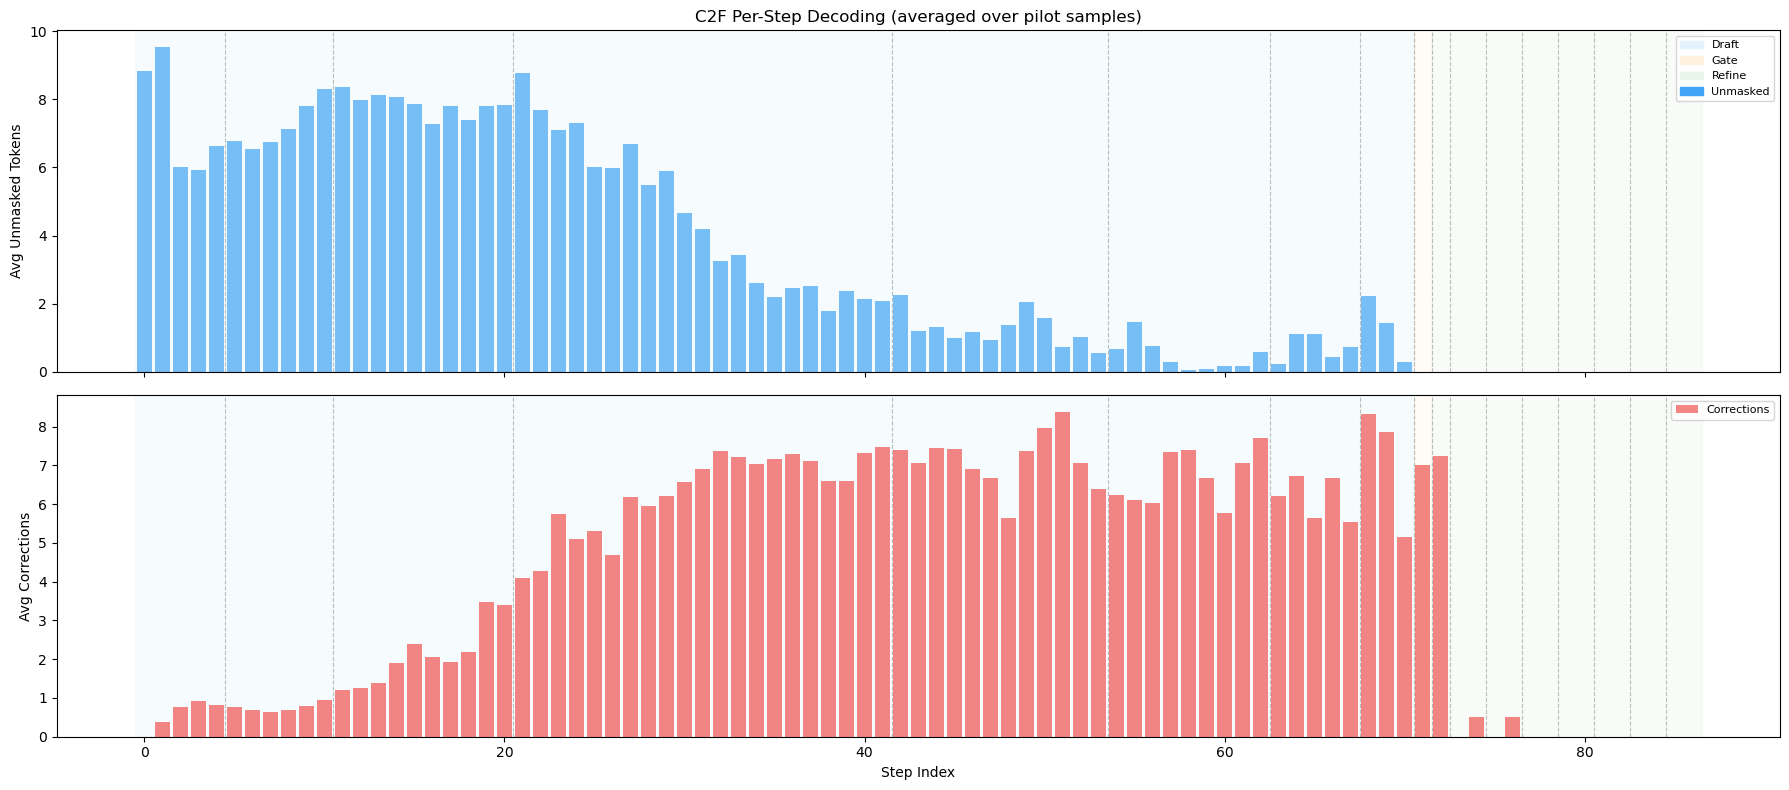

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_per_step_decoding(corr_logs, title='Per-Step Decoding (averaged)',
                           save_path=None):
    """Plot per-step unmasked tokens for skeleton-first strategy."""
    if not corr_logs:
        print('No corr_logs to plot')
        return

    max_len = max(len(log) for log in corr_logs)

    unmasked_arr = np.zeros((len(corr_logs), max_len))
    remaining_arr = np.zeros((len(corr_logs), max_len))
    counts = np.zeros(max_len)

    for si, log in enumerate(corr_logs):
        for step_i, entry in enumerate(log):
            unmasked_arr[si, step_i] = entry['unmasked']
            remaining_arr[si, step_i] = entry['remaining']
            counts[step_i] += 1

    avg_unmasked = unmasked_arr.sum(axis=0) / np.maximum(counts, 1)
    avg_remaining = remaining_arr.sum(axis=0) / np.maximum(counts, 1)

    ref_log = max(corr_logs, key=len)

    fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
    steps_x = np.arange(len(ref_log))

    phase_colors = {'skeleton': '#E3F2FD', 'fill': '#E8F5E9'}

    prev_phase = None
    phase_start = 0
    phase_ranges = []
    for i, entry in enumerate(ref_log):
        phase = entry.get('phase', 'fill')
        if phase != prev_phase:
            if prev_phase is not None:
                phase_ranges.append((phase_start, i, prev_phase))
            phase_start = i
            prev_phase = phase
    phase_ranges.append((phase_start, len(ref_log), prev_phase))

    for ax in axes:
        for start, end, phase in phase_ranges:
            ax.axvspan(start - 0.5, end - 0.5, alpha=0.3,
                       color=phase_colors.get(phase, '#F5F5F5'), zorder=0)

    block_boundaries = []
    prev_block = None
    for i, entry in enumerate(ref_log):
        blk = entry.get('block', -1)
        if blk != prev_block and prev_block is not None:
            block_boundaries.append(i)
        prev_block = blk

    for ax in axes:
        for bx in block_boundaries:
            ax.axvline(bx - 0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

    ax0 = axes[0]
    ax0.bar(steps_x, avg_unmasked[:len(ref_log)], color='#42A5F5', alpha=0.7, label='Unmasked')
    ax0.set_ylabel('Avg Unmasked Tokens')
    ax0.set_title(title)

    ax1 = axes[1]
    ax1.plot(steps_x, avg_remaining[:len(ref_log)], color='#EF6C00', linewidth=1.5, label='Remaining MASK')
    ax1.set_ylabel('Avg Remaining MASK')
    ax1.set_xlabel('Step Index')

    patches = [mpatches.Patch(color=phase_colors[p], label=p.capitalize()) for p in ['skeleton', 'fill']]
    axes[0].legend(handles=patches + [mpatches.Patch(color='#42A5F5', label='Unmasked')],
                   loc='upper right', fontsize=8)
    axes[1].legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


sk_data = all_results.get('skeleton_first', {})
sk_corr_logs = [r['corr_log'] for r in sk_data.get('results', []) if 'corr_log' in r]

if sk_corr_logs:
    plot_per_step_decoding(
        sk_corr_logs,
        title='Skeleton-First Per-Step Decoding (threshold=0.9)',
        save_path='correction_analysis/skeleton_per_step.png',
    )
else:
    print('No corr_log data available for skeleton_first.')

## 7. Per-Block 解码/修改统计

X 轴 = Block 编号，Y 轴 = 该 block 累计 unmasked / corrections。
分别显示 Phase 1 (Draft) 和 Phase 2 (Refine) 的贡献，右侧 Y 轴标注该 block 在 Refine 阶段的 threshold 值。

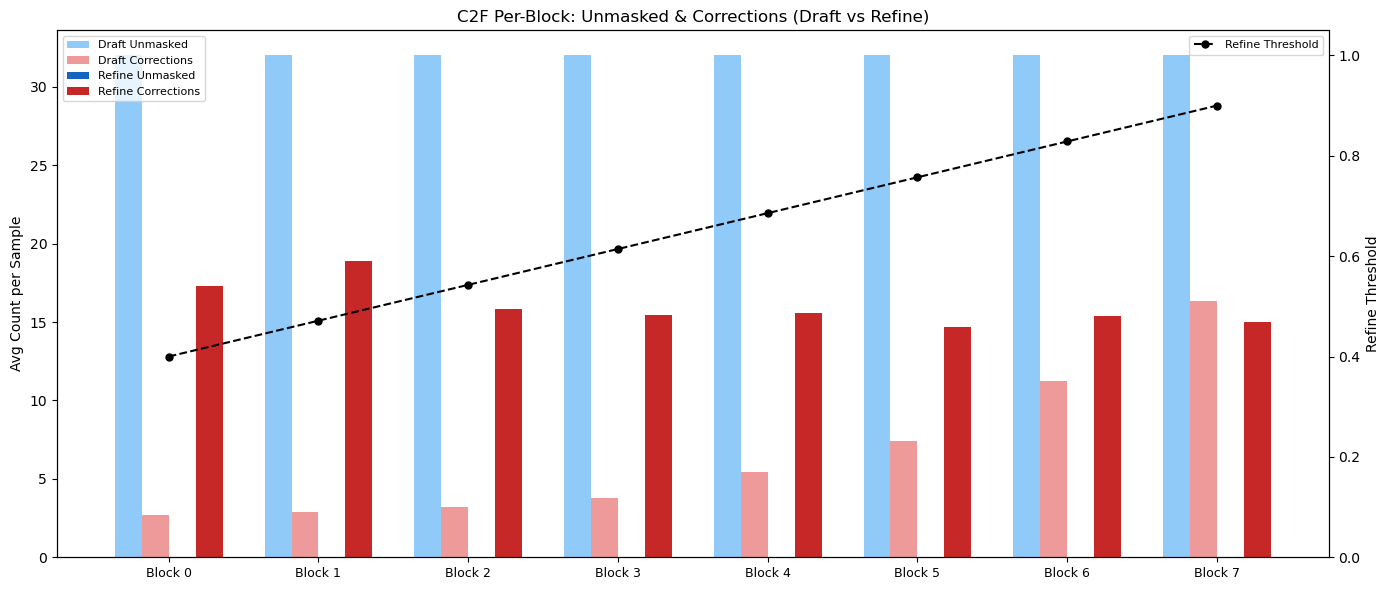

In [8]:
def plot_per_block_stats(corr_logs, num_blocks=8,
                         title='Per-Block Statistics',
                         save_path=None):
    """Per-block grouped bar chart: skeleton unmasked vs fill unmasked."""
    if not corr_logs:
        print('No corr_logs to plot')
        return

    skeleton_unmasked = np.zeros(num_blocks)
    fill_unmasked = np.zeros(num_blocks)
    fill_remaining = np.zeros(num_blocks)
    n_samples = len(corr_logs)

    for log in corr_logs:
        # Skeleton round: block == -1, but we can attribute unmasked to blocks
        # by position. For simplicity, just count fill-phase per block.
        for entry in log:
            blk = entry.get('block', -1)
            if blk < 0 or blk >= num_blocks:
                continue
            phase = entry.get('phase', 'fill')
            u = entry.get('unmasked', 0)
            if phase == 'skeleton':
                skeleton_unmasked[blk] += u
            else:
                fill_unmasked[blk] += u

        # Track final remaining per block from last fill entry
        for entry in reversed(log):
            blk = entry.get('block', -1)
            if 0 <= blk < num_blocks and entry.get('phase') == 'fill':
                fill_remaining[blk] += entry.get('remaining', 0)
                break

    skeleton_unmasked /= n_samples
    fill_unmasked /= n_samples
    fill_remaining /= n_samples

    x_pos = np.arange(num_blocks)
    w = 0.3

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.bar(x_pos - w / 2, skeleton_unmasked, w, label='Skeleton Unmasked (head+tail)', color='#90CAF9')
    ax.bar(x_pos + w / 2, fill_unmasked, w, label='Fill Unmasked (DualCache)', color='#1565C0')

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'Block {i}' for i in range(num_blocks)], fontsize=9)
    ax.set_ylabel('Avg Unmasked per Sample')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)

    ax2 = ax.twinx()
    ax2.plot(x_pos, fill_remaining, 'r--o', markersize=5, linewidth=1.5, label='Remaining MASK after Fill')
    ax2.set_ylabel('Avg Remaining MASK', fontsize=10)
    ax2.legend(loc='upper left', fontsize=8)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


num_blocks_cfg = GEN_LENGTH // BLOCK_LENGTH

if sk_corr_logs:
    plot_per_block_stats(
        sk_corr_logs,
        num_blocks=num_blocks_cfg,
        title='Skeleton-First Per-Block: Skeleton vs Fill',
        save_path='correction_analysis/skeleton_per_block.png',
    )
else:
    print('No corr_log data available for skeleton_first.')

## 8. Round 2 vs Baseline: NFE & 解码效率对比

In [ ]:
def plot_nfe_and_speed_comparison(all_results, skeleton_key='skeleton_first',
                                   baseline_key='baseline_t0.9',
                                   save_path=None):
    """Compare skeleton Round 1/2 NFE breakdown and per-block fill efficiency vs baseline."""
    sk = all_results.get(skeleton_key)
    bl = all_results.get(baseline_key)
    if sk is None or bl is None:
        print(f'Missing data: skeleton={sk is not None}, baseline={bl is not None}')
        return

    # --- NFE breakdown ---
    sk_logs = [r['corr_log'] for r in sk['results'] if 'corr_log' in r]
    bl_logs = [r.get('corr_log', []) for r in bl.get('results', [])]

    sk_r1_nfe = np.mean([sum(1 for e in log if e.get('phase') == 'skeleton') for log in sk_logs])
    sk_r2_nfe = np.mean([sum(1 for e in log if e.get('phase') == 'fill') for log in sk_logs])
    bl_total_nfe = bl['avg_nfe']

    # --- Per-block tokens unmasked (fill phase only for skeleton, all for baseline) ---
    num_blocks = GEN_LENGTH // BLOCK_LENGTH
    sk_fill_per_block = np.zeros(num_blocks)
    bl_fill_per_block = np.zeros(num_blocks)

    for log in sk_logs:
        for entry in log:
            blk = entry.get('block', -1)
            if 0 <= blk < num_blocks and entry.get('phase') == 'fill':
                sk_fill_per_block[blk] += entry.get('unmasked', 0)
    sk_fill_per_block /= max(len(sk_logs), 1)

    for log in bl_logs:
        for entry in log:
            blk = entry.get('block', -1)
            if 0 <= blk < num_blocks:
                bl_fill_per_block[blk] += entry.get('unmasked', 0)
    bl_fill_per_block /= max(len(bl_logs), 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # (a) NFE breakdown
    ax = axes[0]
    ax.bar(0, bl_total_nfe, width=0.5, color='#90CAF9', label='Baseline Total NFE')
    ax.bar(1, sk_r1_nfe, width=0.5, color='#FFB74D', label='Skeleton R1 (skeleton)')
    ax.bar(1, sk_r2_nfe, width=0.5, bottom=sk_r1_nfe, color='#66BB6A', label='Skeleton R2 (fill)')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['baseline_t0.9', 'skeleton_first'])
    ax.set_ylabel('Avg NFE per Sample')
    ax.set_title('(a) NFE Breakdown')
    for i, (v, y) in enumerate([(bl_total_nfe, bl_total_nfe),
                                 (sk_r1_nfe + sk_r2_nfe, sk_r1_nfe + sk_r2_nfe)]):
        ax.text(i, y + 0.5, f'{v:.1f}', ha='center', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')

    # (b) Per-block fill tokens
    ax = axes[1]
    x_pos = np.arange(num_blocks)
    w = 0.35
    ax.bar(x_pos - w/2, bl_fill_per_block, w, label='Baseline', color='#90CAF9')
    ax.bar(x_pos + w/2, sk_fill_per_block, w, label='Skeleton R2', color='#66BB6A')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'B{i}' for i in range(num_blocks)], fontsize=8)
    ax.set_ylabel('Avg Tokens Unmasked')
    ax.set_title('(b) Per-Block Tokens Unmasked')
    ax.legend(fontsize=8)

    # (c) Tokens/s and Tok/NFE
    ax = axes[2]
    bl_tps = bl.get('tokens_per_second', 0)
    sk_tps = sk.get('tokens_per_second', 0)
    bl_tok_nfe = bl['total_gen_tokens'] / bl['total_nfe'] if bl['total_nfe'] > 0 else 0
    sk_tok_nfe = sk['total_gen_tokens'] / sk['total_nfe'] if sk['total_nfe'] > 0 else 0

    x = np.arange(2)
    w2 = 0.35
    bars1 = ax.bar(x - w2/2, [bl_tps, sk_tps], w2, label='Tok/s', color='#42A5F5')
    ax2 = ax.twinx()
    bars2 = ax2.bar(x + w2/2, [bl_tok_nfe, sk_tok_nfe], w2, label='Tok/NFE', color='#FFA726')
    ax.set_xticks(x)
    ax.set_xticklabels(['baseline_t0.9', 'skeleton_first'], fontsize=9)
    ax.set_ylabel('Tokens / second')
    ax2.set_ylabel('Tokens / NFE')
    ax.set_title('(c) Speed Comparison')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

    for bar, val in zip(bars1, [bl_tps, sk_tps]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', fontsize=8)
    for bar, val in zip(bars2, [bl_tok_nfe, sk_tok_nfe]):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', fontsize=8)

    plt.suptitle('Skeleton-First vs Baseline (threshold=0.9)', fontsize=12, y=1.02)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_nfe_and_speed_comparison(
    all_results,
    save_path='correction_analysis/skeleton_vs_baseline.png',
)

## 9. 结果汇总

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

display_order = ['baseline_t0.9', 'skeleton_first']

rows = []
for name in display_order:
    data = all_results.get(name)
    if data is None:
        print(f'[WARN] {name} not found in all_results, skipping.')
        continue
    rows.append({
        'Config': name,
        'Flex Acc': f"{data['flex_acc']:.2%}",
        'Strict Acc': f"{data['strict_acc']:.2%}",
        'Flex+-SE': f"{data['flex_acc']:.2f}+-{data.get('flex_se', 0):.4f}",
        'Strict+-SE': f"{data['strict_acc']:.2f}+-{data.get('strict_se', 0):.4f}",
        'Avg NFE': f"{data['avg_nfe']:.1f}",
        'Total NFE': f"{data['total_nfe']}",
        'Avg Corrections': f"{data['avg_corrections']:.1f}",
        'Tokens': f"{data.get('total_gen_tokens', 'N/A')}",
        'Tok/s': f"{data.get('tokens_per_second', 0):.1f}",
        'Time (s)': f"{data['elapsed']:.0f}",
    })

df_results = pd.DataFrame(rows)

for name in display_order:
    data = all_results.get(name)
    if data is None:
        continue
    print(f'\n===== {name} =====')
    print(f'Total number of tokens generated: {data.get("total_gen_tokens", "N/A")}')
    print(f'Total time taken: {data["elapsed"]:.2f} seconds')
    print(f'Tokens per second: {data.get("tokens_per_second", 0):.2f}')
    print(f'Total NFE is {data["total_nfe"]}')
    print(f'\n|Tasks|Version|     Filter     |n-shot|  Metric   |   |Value|   |Stderr|')
    print(f'|-----|------:|----------------|-----:|-----------|---|----:|---|-----:|')
    print(f'|gsm8k|      3|flexible-extract|     5|exact_match|^  |{data["flex_acc"]:5.2f}|+-  |{data.get("flex_se",0):.4f}|')
    print(f'|     |       |strict-match    |     5|exact_match|^  |{data["strict_acc"]:5.2f}|+-  |{data.get("strict_se",0):.4f}|')

print('\n')
print(df_results.to_string(index=False))
display(df_results)


Total number of tokens generated: 102400
Total time taken: 4733.779927968979 seconds
Tokens per second: 21.63176183898658
Total NFE is 18640

|Tasks|Version|     Filter     |n-shot|  Metric   |   |Value|   |Stderr|
|-----|------:|----------------|-----:|-----------|---|----:|---|-----:|
|gsm8k|      3|flexible-extract|     5|exact_match|↑  | 0.33|±  |0.0234|
|     |       |strict-match    |     5|exact_match|↑  | 0.12|±  |0.0162|


     Config Flex Acc Strict Acc     Flex±SE   Strict±SE Avg NFE Total NFE Avg Corrections Tokens Tok/s Time (s)
c2f_default   32.50%     12.00% 0.33±0.0234 0.12±0.0162    46.6     18640           192.5 102400  21.6     4734


,Config,Flex Acc,Strict Acc,Flex±SE,Strict±SE,Avg NFE,Total NFE,Avg Corrections,Tokens,Tok/s,Time (s)
0,c2f_default,32.50%,12.00%,0.33±0.0234,0.12±0.0162,46.6,18640,192.5,102400,21.6,4734


In [10]:
from IPython.display import Javascript
display(Javascript('IPython.notebook.save_checkpoint()'))

<IPython.core.display.Javascript object>